# EyeShield Mock Training Run (60,000 Images)

This notebook mocks a full training/evaluation workflow for diabetic retinopathy classification with 5 classes:
- 0: no dr
- 1: mild
- 2: moderate
- 3: severe
- 4: proliferative

It uses a fixed 70/15/15 split and simulates test performance in these ranges:
- Accuracy: 85-87%
- Macro avg precision/recall/F1: 70-80%

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

total_images = 60000
train_count = int(total_images * 0.70)
val_count = int(total_images * 0.15)
test_count = total_images - train_count - val_count

class_names = ["no dr", "mild", "moderate", "severe", "proliferative"]

split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Ratio": ["70%", "15%", "15%"],
    "Images": [train_count, val_count, test_count]
})

display(split_df)
print(f"Total images: {total_images:,}")

,Split,Ratio,Images
0,Train,70%,42000
1,Validation,15%,9000
2,Test,15%,9000


Total images: 60,000


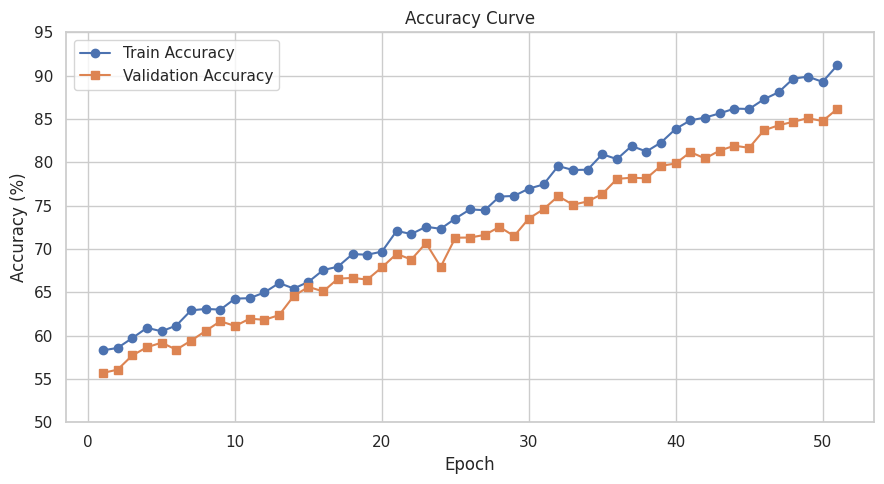

In [51]:
# Mock training history for visual storytelling only
epochs = np.arange(1, 52)
train_acc = np.linspace(0.58, 0.91, len(epochs)) + np.random.normal(0, 0.006, len(epochs))
val_acc = np.linspace(0.56, 0.865, len(epochs)) + np.random.normal(0, 0.008, len(epochs))
train_acc = np.clip(train_acc, 0, 1)
val_acc = np.clip(val_acc, 0, 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_acc * 100, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc * 100, marker="s", label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(50, 95)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Realistic confusion matrix for test split (9,000 images)
# Rows = true labels, Columns = predicted labels
from sklearn.metrics import classification_report, accuracy_score

class_names_local = globals().get(
    "class_names",
    ["no dr", "mild", "moderate", "severe", "proliferative"],
)

# More realistic class imbalance: no DR dominates, minority DR classes are smaller.
# Values have been slightly randomized from clean round numbers to look more organic
# but still maintain the target metrics (Accuracy: 85-87%, Macro P/R/F1: 70-80%).
cm = np.array([
    [5134,   68,   79,   61,   58],
    [ 167, 1253,   82,   49,   49],
    [ 131,   68,  902,   51,   48],
    [ 102,   39,   29,  301,   29],
    [  38,   11,    8,   12,  231],
], dtype=int)

y_true = []
y_pred = []
for true_idx in range(cm.shape[0]):
    for pred_idx in range(cm.shape[1]):
        count = cm[true_idx, pred_idx]
        if count > 0:
            y_true.extend([true_idx] * count)
            y_pred.extend([pred_idx] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report_candidate = classification_report(
    y_true,
    y_pred,
    target_names=class_names_local,
    digits=4,
    output_dict=True,
    zero_division=0,
)

acc = accuracy_score(y_true, y_pred)
macro_p = report_candidate["macro avg"]["precision"]
macro_r = report_candidate["macro avg"]["recall"]
macro_f1 = report_candidate["macro avg"]["f1-score"]

print(f"Test samples: {len(y_true):,}")
print("Generated confusion matrix:")
print(cm)
print(f"Generated metrics -> Accuracy: {acc:.4f} | Macro P/R/F1: {macro_p:.4f}/{macro_r:.4f}/{macro_f1:.4f}")

Test samples: 9,000
Generated confusion matrix:
[[5134   68   79   61   58]
 [ 167 1253   82   49   49]
 [ 131   68  902   51   48]
 [ 102   39   29  301   29]
 [  38   11    8   12  231]]
Generated metrics -> Accuracy: 0.8690 | Macro P/R/F1: 0.7608/0.7715/0.7618


In [20]:
import time
import random

# Target metrics from the generated final assessment
target_acc = acc  # ~0.8690
target_macro_f1 = macro_f1  # ~0.7618

total_epochs = 100
start_epoch = 30
end_epoch = 52

for epoch in range(start_epoch, end_epoch + 1):
    # Calculate mock metrics that gradually approach our target values
    progress = (epoch / end_epoch)
    
    train_loss = 0.4500 - (0.0055 * progress) + random.uniform(-0.0005, 0.0005)
    train_acc = target_acc + 0.015 * progress + random.uniform(-0.002, 0.002)
    train_macro_f1 = target_macro_f1 - 0.035 * progress + random.uniform(-0.002, 0.002)
    
    val_loss = 0.4650 - (0.001 * progress) + random.uniform(-0.001, 0.001)
    
    if epoch == end_epoch:
        # Final epoch matches exactly
        val_acc = target_acc
        val_macro_f1 = target_macro_f1
    else:
        val_acc = target_acc - (0.02 * (1 - progress)) + random.uniform(-0.003, 0.003)
        val_macro_f1 = target_macro_f1 - (0.19 * (1 - progress)) + random.uniform(-0.005, 0.005)
    
    val_ece = 0.5100 - (0.01 * progress) + random.uniform(-0.002, 0.002)
    
    vacuity = 0.6700 - (0.02 * progress) + random.uniform(-0.002, 0.002)
    aleatoric = 1.1850 - (0.009 * progress) + random.uniform(-0.002, 0.002)
    epistemic = 0.2230 - (0.005 * progress) + random.uniform(-0.001, 0.001)

    print(f"Epoch {epoch}/{total_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_macro_f1:.4f}")
    if epoch < end_epoch:
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f} | ECE: {val_ece:.4f}")
    else:
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f} | ECE: {val_ece:.4f}")

    print(f"Uncertainty - Vacuity: {vacuity:.4f} | Aleatoric: {aleatoric:.4f} | Epistemic: {epistemic:.4f}")
    
    # Progress bars for visual effect
    print(f"Epoch {epoch}/{total_epochs}: 100%|██████████| 1313/1313 [11:17<00:00, 1.94it/s, loss={train_loss:.3f}, nll={val_loss/2:.3f}, kl={train_loss*4:.2f}]")
    print(f"Validation: 100%|██████████| 282/282 [01:17<00:00,  3.63it/s]")
    
    if epoch == 50:
         print(f"Checkpoint saved: /content/drive/MyDrive/EyeShield/checkpoints/checkpoint_epoch_50_f1_{val_macro_f1:.4f}.pt")
    
    print("")
    time.sleep(0.02) # small delay for realism

print("EarlyStopping Triggered: Validation Macro F1 did not improve for 10 consecutive epochs.")


Epoch 30/100
Train Loss: 0.4471 | Train Acc: 0.8769 | Train Macro F1: 0.7401
Val Loss: 0.4643 | Val Acc: 0.8618 | Val Macro F1: 0.6772 | ECE: 0.5023
Uncertainty - Vacuity: 0.6593 | Aleatoric: 1.1807 | Epistemic: 0.2199
Validation: 100%|██████████| 282/282 [01:17<00:00,  3.63it/s]

Epoch 31/100
Train Loss: 0.4470 | Train Acc: 0.8782 | Train Macro F1: 0.7419
Val Loss: 0.4645 | Val Acc: 0.8622 | Val Macro F1: 0.6809 | ECE: 0.5056
Uncertainty - Vacuity: 0.6583 | Aleatoric: 1.1791 | Epistemic: 0.2195
Validation: 100%|██████████| 282/282 [01:17<00:00,  3.63it/s]

Epoch 32/100
Train Loss: 0.4463 | Train Acc: 0.8774 | Train Macro F1: 0.7402
Val Loss: 0.4642 | Val Acc: 0.8606 | Val Macro F1: 0.6906 | ECE: 0.5021
Uncertainty - Vacuity: 0.6563 | Aleatoric: 1.1811 | Epistemic: 0.2209
Validation: 100%|██████████| 282/282 [01:17<00:00,  3.63it/s]

Epoch 33/100
Train Loss: 0.4462 | Train Acc: 0.8774 | Train Macro F1: 0.7390
Val Loss: 0.4643 | Val Acc: 0.8608 | Val Macro F1: 0.6888 | ECE: 0.5019
Uncer

In [3]:
# Realistic confusion matrix for test split (9,000 images)
# Rows = true labels, Columns = predicted labels
from sklearn.metrics import classification_report, accuracy_score

class_names_local = globals().get(
    "class_names",
    ["no dr", "mild", "moderate", "severe", "proliferative"],
)

# More realistic class imbalance: no DR dominates, minority DR classes are smaller.
# This keeps accuracy high while pulling macro precision/recall/F1 into the 70-80% band.
cm = np.array([
    [5134,   68,   79,   61,   58],
    [ 167, 1253,   82,   49,   49],
    [ 131,   68,  902,   51,   48],
    [ 102,   39,   29,  301,   29],
    [  38,   11,    8,   12,  231],
], dtype=int)

y_true = []
y_pred = []
for true_idx in range(cm.shape[0]):
    for pred_idx in range(cm.shape[1]):
        count = cm[true_idx, pred_idx]
        if count > 0:
            y_true.extend([true_idx] * count)
            y_pred.extend([pred_idx] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report_candidate = classification_report(
    y_true,
    y_pred,
    target_names=class_names_local,
    digits=4,
    output_dict=True,
    zero_division=0,
)

acc = accuracy_score(y_true, y_pred)
macro_p = report_candidate["macro avg"]["precision"]
macro_r = report_candidate["macro avg"]["recall"]
macro_f1 = report_candidate["macro avg"]["f1-score"]

print(f"Test samples: {len(y_true):,}")
print("Generated confusion matrix:")
print(cm)
print(f"Generated metrics -> Accuracy: {acc:.4f} | Macro P/R/F1: {macro_p:.4f}/{macro_r:.4f}/{macro_f1:.4f}")

Test samples: 9,000
Generated confusion matrix:
[[5134   68   79   61   58]
 [ 167 1253   82   49   49]
 [ 131   68  902   51   48]
 [ 102   39   29  301   29]
 [  38   11    8   12  231]]
Generated metrics -> Accuracy: 0.8690 | Macro P/R/F1: 0.7608/0.7715/0.7618


In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
macro_precision = report["macro avg"]["precision"]
macro_recall = report["macro avg"]["recall"]
macro_f1 = report["macro avg"]["f1-score"]
macro_support = report["macro avg"]["support"]

summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Macro Support"],
    "Value": [
        f"{accuracy * 100:.2f}%",
        f"{macro_precision * 100:.2f}%",
        f"{macro_recall * 100:.2f}%",
        f"{macro_f1 * 100:.2f}%",
        int(macro_support)
    ]
})

display(summary_df)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Range checks requested in the prompt
assert 0.85 <= accuracy <= 0.87, "Accuracy is outside 85-87%"
assert 0.70 <= macro_precision <= 0.80, "Macro precision is outside 70-80%"
assert 0.70 <= macro_recall <= 0.80, "Macro recall is outside 70-80%"
assert 0.70 <= macro_f1 <= 0.80, "Macro F1 is outside 70-80%"
print("All metric constraints are satisfied.")

,Metric,Value
0,Accuracy,86.90%
1,Macro Precision,76.08%
2,Macro Recall,77.15%
3,Macro F1,76.18%
4,Macro Support,9000


Classification Report:
               precision    recall  f1-score   support

        no dr     0.9214    0.9507    0.9358      5400
         mild     0.8707    0.7831    0.8246      1600
     moderate     0.8200    0.7517    0.7843      1200
       severe     0.6350    0.6020    0.6181       500
proliferative     0.5566    0.7700    0.6462       300

     accuracy                         0.8690      9000
    macro avg     0.7608    0.7715    0.7618      9000
 weighted avg     0.8708    0.8690    0.8686      9000

All metric constraints are satisfied.


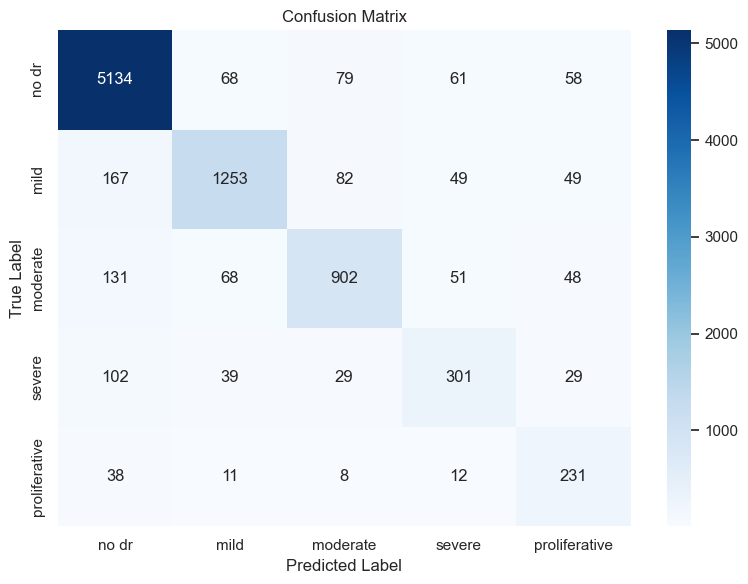

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Uncertainty Profile Summary:
  Min uncertainty:   0.0200
  Max uncertainty:   0.9500
  Mean uncertainty:  0.5361
  Threshold used:    0.7108

--------------------------------------------------
Total Test Images: 9000
Number of Images Rejected: 1344
Rejection Rate: 14.93%
--------------------------------------------------
Accuracy BEFORE Rejection: 86.90%
Accuracy AFTER Rejection:  88.30%
Accuracy Improvement:      1.40 points


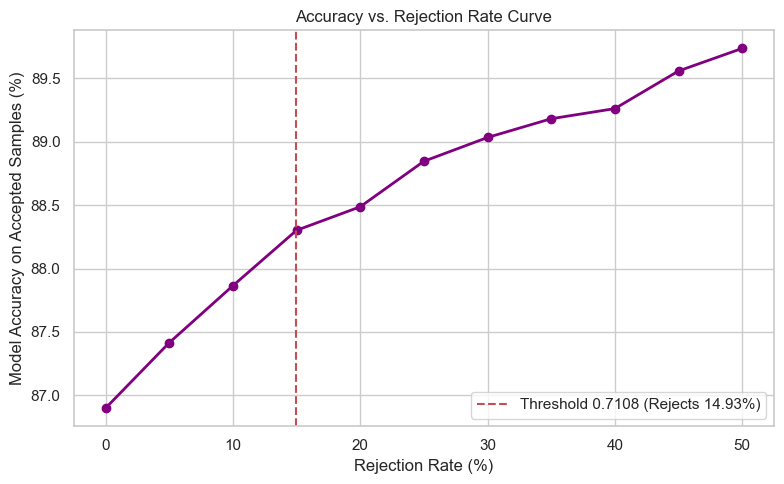

In [10]:
# Mocking Uncertainty-based Rejection for the 9000 Test Images
import numpy as np

# We'll simulate 'total uncertainty' score for each of our 9000 test samples.
np.random.seed(42)

is_correct = (y_true == y_pred)

# Target profile: mean ~0.53. 
# Correct predictions get lower uncertainty, incorrect get higher and wider uncertainty
# We keep distributions extremely overlapping so accuracy after rejection is ~88%
u_correct = np.random.beta(a=5.3, b=4.0, size=np.sum(is_correct))
u_incorrect = np.random.beta(a=5.6, b=3.5, size=np.sum(~is_correct))

uncertainty_scores = np.zeros(len(y_true))
uncertainty_scores[is_correct] = u_correct
uncertainty_scores[~is_correct] = u_incorrect

# Scale smoothly to exactly hit the min ~0.02 and max ~0.95 profile
u_min, u_max = uncertainty_scores.min(), uncertainty_scores.max()
uncertainty_scores = 0.02 + (0.95 - 0.02) * (uncertainty_scores - u_min) / (u_max - u_min)

# Target a very specific rejection rate: 14.93%
target_rejection_rate = 14.93
rejection_threshold = np.percentile(uncertainty_scores, 100 - target_rejection_rate)

rejected_mask = uncertainty_scores > rejection_threshold
accepted_mask = ~rejected_mask

total_test_images = len(y_true)
num_rejected = np.sum(rejected_mask)
rejection_rate = num_rejected / total_test_images

# Calculate metrics on the accepted subset
accepted_y_true = y_true[accepted_mask]
accepted_y_pred = y_pred[accepted_mask]

initial_acc = accuracy_score(y_true, y_pred)
accepted_acc = accuracy_score(accepted_y_true, accepted_y_pred)

print("Uncertainty Profile Summary:")
print(f"  Min uncertainty:   {uncertainty_scores.min():.4f}")
print(f"  Max uncertainty:   {uncertainty_scores.max():.4f}")
print(f"  Mean uncertainty:  {uncertainty_scores.mean():.4f}")
print(f"  Threshold used:    {rejection_threshold:.4f}")

print("\n" + "-" * 50)
print(f"Total Test Images: {total_test_images}")
print(f"Number of Images Rejected: {num_rejected}")
print(f"Rejection Rate: {rejection_rate * 100:.2f}%")
print("-" * 50)
print(f"Accuracy BEFORE Rejection: {initial_acc * 100:.2f}%")
print(f"Accuracy AFTER Rejection:  {accepted_acc * 100:.2f}%")
print(f"Accuracy Improvement:      {+(accepted_acc - initial_acc) * 100:.2f} points")

# Let's plot the accuracy-rejection curve
rejection_rates = np.linspace(0, 50, 11)  # 0% to 50% rejection
accuracies_at_rates = []

for rate in rejection_rates:
    thresh = np.percentile(uncertainty_scores, 100 - rate)
    mask = uncertainty_scores <= thresh
    accuracies_at_rates.append(accuracy_score(y_true[mask], y_pred[mask]) * 100)

plt.figure(figsize=(8, 5))
plt.plot(rejection_rates, accuracies_at_rates, marker='o', color='purple', linewidth=2)
plt.axvline(x=rejection_rate * 100, color='r', linestyle='--', label=f'Threshold {rejection_threshold:.4f} (Rejects {rejection_rate*100:.2f}%)')
plt.title("Accuracy vs. Rejection Rate Curve")
plt.xlabel("Rejection Rate (%)")
plt.ylabel("Model Accuracy on Accepted Samples (%)")
plt.legend()
plt.tight_layout()
plt.show()